# Seaborn Distribution plots

How to look at the shape of a single variable, or two variables together.
The four functions: `histplot`, `kdeplot`, `ecdfplot`, `rugplot`. Plus
`displot` as their figure-level wrapper.


## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Run "pip install seaborn" if you don't have it installed yet

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(0)

penguins = sns.load_dataset("penguins")
tips = sns.load_dataset("tips")

In [3]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## histplot — counting values into bins

A **histogram** divides the range of a variable into bins and counts how
many observations fall in each bin. The y-axis is count by default.


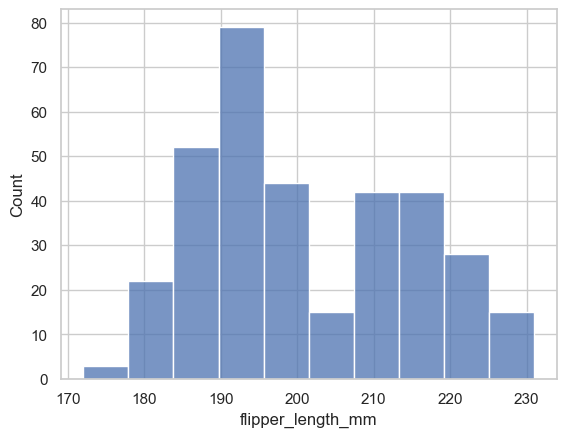

In [4]:
sns.histplot(data=penguins, x="flipper_length_mm")
plt.show()

Bin width matters more than people think. Too few bins hides
structure; too many bins shows noise.

Three ways to control bins:
- `bins=30` — integer count.
- `binwidth=2` — fixed width in data units.
- `bins="auto"` — Freedman-Diaconis rule, usually sensible.


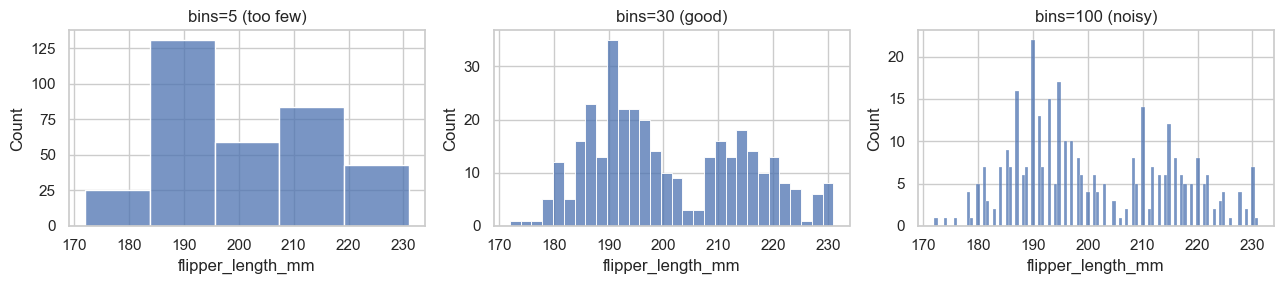

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

sns.histplot(data=penguins, x="flipper_length_mm", bins=5, ax=axes[0])
axes[0].set_title("bins=5 (too few)")

sns.histplot(data=penguins, x="flipper_length_mm", bins=30, ax=axes[1])
axes[1].set_title("bins=30 (good)")

sns.histplot(data=penguins, x="flipper_length_mm", bins=100, ax=axes[2])
axes[2].set_title("bins=100 (noisy)")

plt.tight_layout()
plt.show()

### stat — what the y-axis means

By default y is the raw count. Change with `stat=`:

- `count` (default) — raw counts.
- `frequency` — count divided by bin width.
- `density` — area sums to 1. Use this when comparing distributions with
  different sample sizes.
- `probability` — bar heights sum to 1.


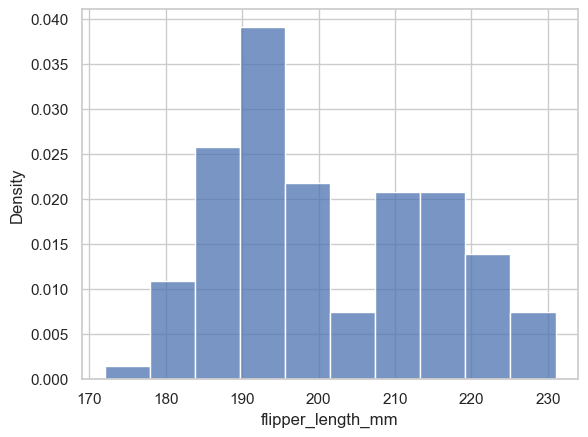

In [6]:
sns.histplot(data=penguins, x="flipper_length_mm", stat="density")
plt.show()

### Comparing groups with hue

`hue` works the same as in scatterplot — color by category. For
distributions there are three ways to stack them visually, controlled by
`multiple`:


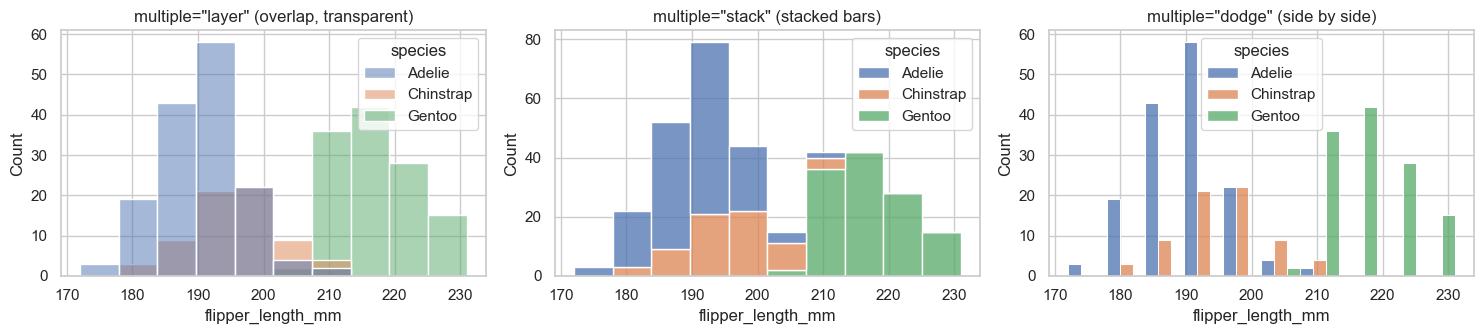

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

sns.histplot(data=penguins, x="flipper_length_mm", hue="species",
             multiple="layer", ax=axes[0])
axes[0].set_title('multiple="layer" (overlap, transparent)')

sns.histplot(data=penguins, x="flipper_length_mm", hue="species",
             multiple="stack", ax=axes[1])
axes[1].set_title('multiple="stack" (stacked bars)')

sns.histplot(data=penguins, x="flipper_length_mm", hue="species",
             multiple="dodge", ax=axes[2])
axes[2].set_title('multiple="dodge" (side by side)')

plt.tight_layout()
plt.show()

When to use which:

- `layer` (default) — best for 2-3 groups with clear separation.
- `stack` — when you care about the total as well as the breakdown.
- `dodge` — when group counts are similar and you want to compare bin-by-bin.


## kdeplot — kernel density estimate

A **KDE** is a smoothed version of a histogram. Instead of counting in
bins, it draws a continuous curve estimating the probability density.

Pros: no bin-width artifacts, easier to compare distributions on the same plot.
Cons: hides the actual data, can imply density where there is none, smooths
over real gaps.


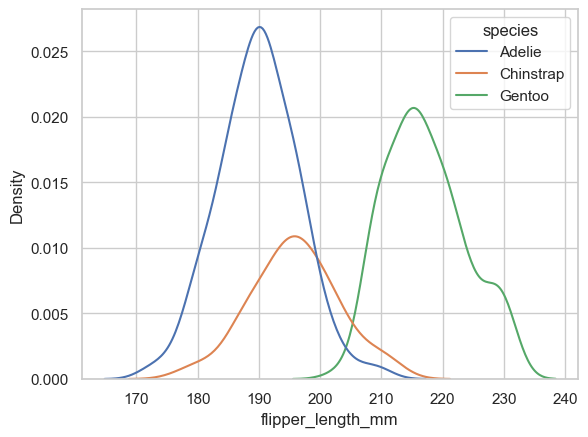

In [8]:
sns.kdeplot(data=penguins, x="flipper_length_mm", hue="species")
plt.show()

### Bandwidth — KDE's bin-width equivalent

The smoothness of the curve is controlled by **bandwidth**, the parameter
`bw_adjust`. Default is 1. Higher values smooth more; lower values
preserve more detail.


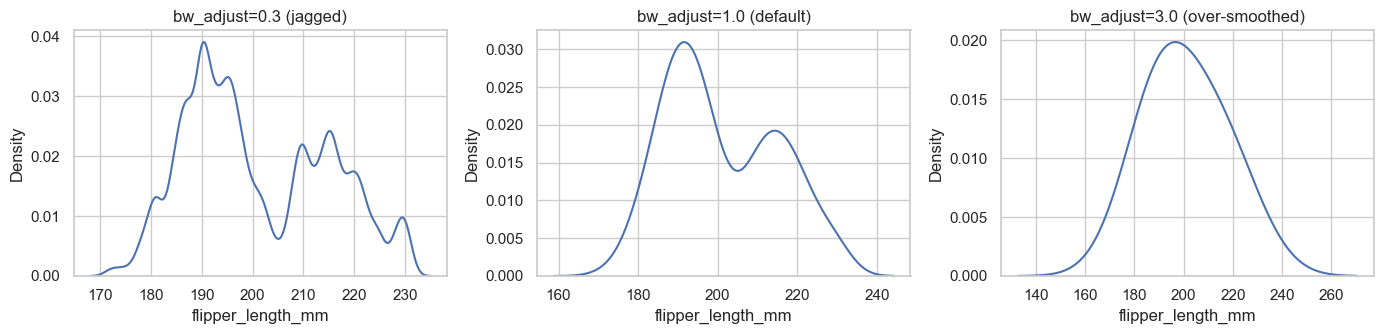

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

sns.kdeplot(data=penguins, x="flipper_length_mm", bw_adjust=0.3, ax=axes[0])
axes[0].set_title("bw_adjust=0.3 (jagged)")

sns.kdeplot(data=penguins, x="flipper_length_mm", bw_adjust=1.0, ax=axes[1])
axes[1].set_title("bw_adjust=1.0 (default)")

sns.kdeplot(data=penguins, x="flipper_length_mm", bw_adjust=3.0, ax=axes[2])
axes[2].set_title("bw_adjust=3.0 (over-smoothed)")

plt.tight_layout()
plt.show()

### Histogram + KDE together

Set `kde=True` on histplot to overlay a KDE on the histogram. Useful when
you want both the actual counts and a smoothed view.


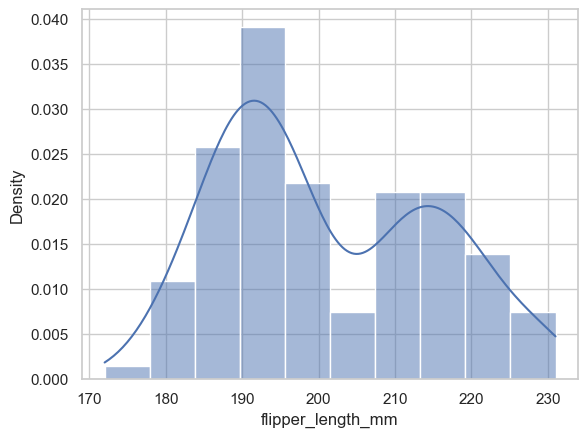

In [10]:
sns.histplot(data=penguins, x="flipper_length_mm", kde=True, stat="density")
plt.show()

## ecdfplot — empirical cumulative distribution function

An **ECDF** plots, for each x value, the fraction of observations less
than or equal to x. It goes from 0 to 1 by construction.

Why use it: no binning, no smoothing, shows the entire dataset exactly.
Reading it takes practice — the y-axis is a percentile, not a density.


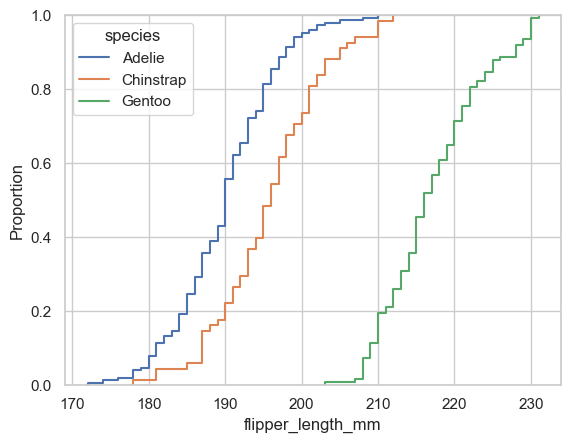

In [11]:
sns.ecdfplot(data=penguins, x="flipper_length_mm", hue="species")
plt.show()

How to read this:

- At any x, the y value is the fraction of penguins with flipper length ≤ x.
- The steepness of the curve at a point indicates density there (steep = many obs).
- A horizontal gap means no observations in that range.

For comparing distributions, ECDFs are often clearer than histograms or
KDEs because the curves cannot overlap in confusing ways.


## rugplot — show every observation

A **rug plot** draws a tick mark at each individual observation. It is
not useful alone but adds detail to other distribution plots.


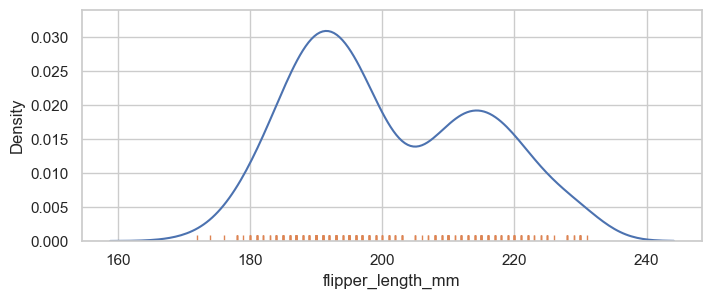

In [12]:
fig, ax = plt.subplots(figsize=(8, 3))
sns.kdeplot(data=penguins, x="flipper_length_mm", ax=ax)
sns.rugplot(data=penguins, x="flipper_length_mm", ax=ax)
plt.show()

The rug shows where actual data points are, exposing where the KDE
is interpolating versus where it has real support.


## Bivariate distributions

All of these work with two variables. Pass both `x` and `y`.


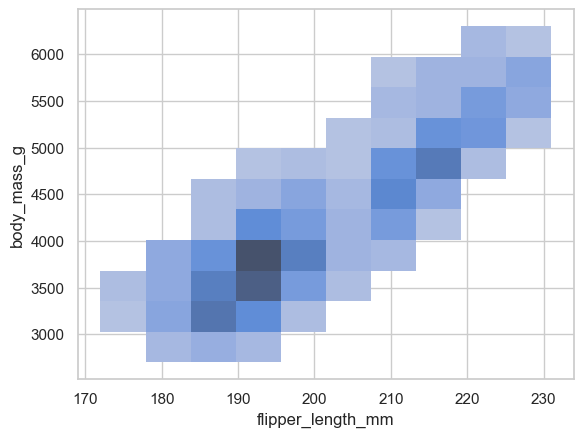

In [13]:
sns.histplot(data=penguins, x="flipper_length_mm", y="body_mass_g")
plt.show()

The 2D histogram is a heatmap of counts. Darker squares = more
penguins in that bill-length / body-mass range.

The 2D KDE shows smooth density contours:


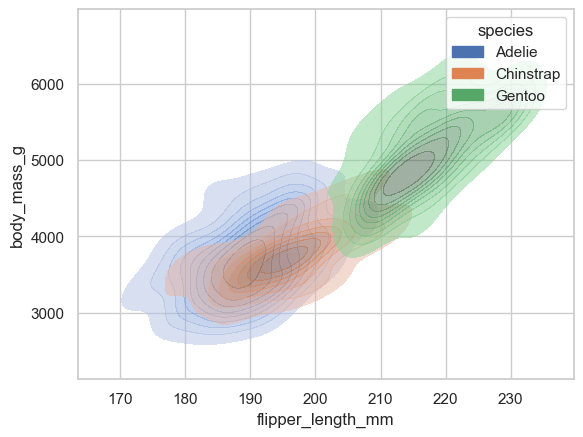

In [14]:
sns.kdeplot(data=penguins, x="flipper_length_mm", y="body_mass_g",
            hue="species", fill=True, alpha=0.5)
plt.show()

`fill=True` fills the contour. `alpha=0.5` makes overlapping species
visible.


## displot — the figure-level version

Recall from Notebook 1: figure-level functions wrap several axes-level
ones and let you facet with `col` and `row`.

`displot` is the figure-level version of `histplot`, `kdeplot`,
`ecdfplot`, and `rugplot`. Switch between them with `kind=`.


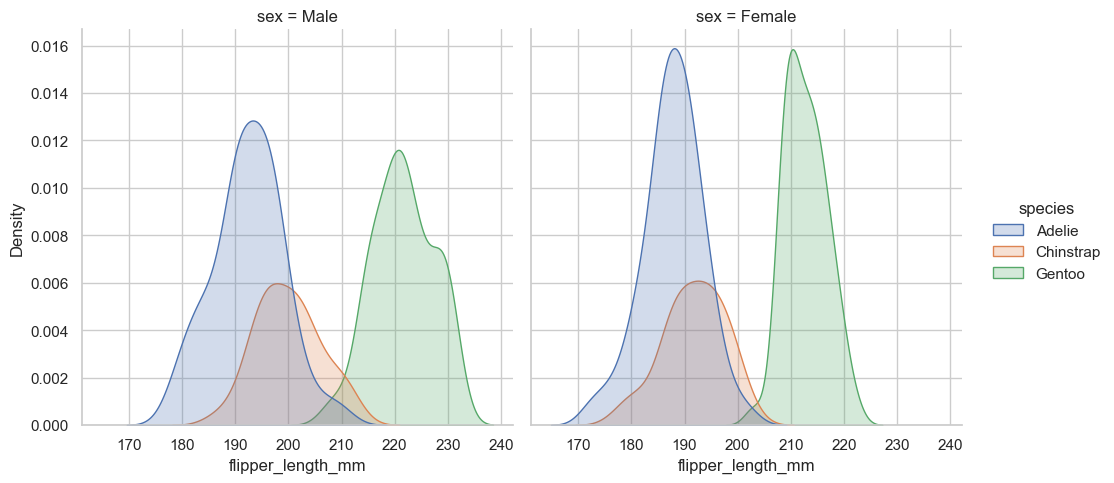

In [15]:
# Same data as before, but split into one panel per sex.
sns.displot(
    data=penguins,
    x="flipper_length_mm",
    hue="species",
    col="sex",
    kind="kde",
    fill=True,
)
plt.show()

Doing this with `kdeplot` directly would require building the
subplot grid yourself.


## Choosing between histogram, KDE, and ECDF

Quick guide:

- **histplot** — default choice. Shows actual counts, no smoothing assumptions.
- **kdeplot** — smoother visual, good for comparing 2-4 groups on one axes.
- **ecdfplot** — best for comparing distributions exactly, especially when
  you care about quantiles or tails.
- **histplot + rugplot** — when sample size is small and you want to see
  every point.

For ML diagnostics later (e.g., comparing predicted vs actual
distributions), ECDFs are often the right tool.




**1. KDE can suggest probability where none exists.** If your variable is
bounded (age ≥ 0, scores ∈ [0, 100]), the KDE will smooth past the boundary.
Use `clip=(low, high)` or just use a histogram.

**2. `bins="auto"` can produce surprising counts.** Reproducibility-wise,
prefer explicit `bins=N` or `binwidth=X` in published plots.

**3. `stat="density"` makes histograms comparable across sample sizes.**
If you forget this and overlay groups of very different size, the larger
group will dominate visually even when proportions are similar.

**4. ECDFs do not support hue with `multiple` — they always overlay.**
This is by design, since stacking cumulative curves makes no sense.
